<a href="https://colab.research.google.com/github/VioletteGL/Interpretabiidad-y-Causalidad-Bourbaki/blob/main/I%26C_2026RETO5_Recomendacion_Backdoor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import warnings
warnings.filterwarnings("ignore")

# Sistemas de recomendación y causalidad. Estimación del sesgo.

Los sistemas de recomendación son algoritmos diseñados para sugerir elementos relevantes a los usuarios. Su objetivo principal es predecir la “calificación” o “preferencia” que un usuario daría a un item.

Existen tres enfoques principales:
1. **Filtrado Colaborativo (CF):** se apoya en similitudes entre usuarios o ítems.
2. **Basado en Contenido:** usa características de los ítems para recomendar.
3. **Modelos Híbridos:** combinan ambos.


### 1. Filtrado Colaborativo (CF)

Este es el enfoque más común, realiza predicciones basadas en los comportamientos pasados de un gran grupo de usuarios.

Hay dos subtipos principales:

-   **Filtrado colaborativo basado en usuarios:** encuentra usuarios similares al usuario objetivo (es decir, que han calificado ítems de manera parecida en el pasado) y recomienda ítems que estos usuarios similares han disfrutado pero que el usuario objetivo aún no ha visto.

*Analogía:* es como preguntar a tus amigos con gustos similares en películas que te recomienden una.

-  **Filtrado colaborativo basado en items:** en lugar de buscar usuarios similares, encuentra ítems similares a los que el usuario ya ha calificado positivamente. Calcula la similitud en función de quién los ha visto, gustado o comprado. Ejemplo: usuarios que compraron Álgebra Lineal y sus Aplicaciones también compraron con frecuencia Introducción a los Algoritmos.

 Es como la función de Amazon “Clientes que compraron este producto también compraron...”.

**Ventajas:**

- No requiere conocer las características de los ítems ni de los usuarios -(agnóstico al contenido).

- Puede generar recomendaciones inesperadas (serendipia), sugiriendo ítems que el usuario no habría descubierto por sí mismo.

**Desventajas:**

- Problema de arranque en frío: difícil recomendar a nuevos usuarios o evaluar ítems nuevos sin historial.

- Escasez de datos: el rendimiento baja cuando la matriz de interacciones usuario-ítem es muy dispersa (sparse).

#### Factorización Matricial (SVD)
Una técnica muy usada en CF es la inspirada en la **factorización matricial (Singular Value Descomposition)**:

Descompone la gran matriz dispersa de interacciones usuario-item (R) en dos matrices más pequeñas y densas:

- Una de características de usuarios (P)  
- Otra de características de items (Q)  

El producto punto entre un vector de usuario en (P) y uno de ítem en (Q) aproxima la calificación esperada:

$$
R \approx P\, Q^{\top}
$$

Con esto podemos predecir la preferencia de un usuario por un item.

Pero si los datos de \(R\) están sesgados (ej. solo vemos películas populares), entonces la factorización **también aprenderá el sesgo**.

## El Problema de los Confusores
- **Confusores (confounders):** Son variables que afectan tanto la exposición como el resultado.
- Ejemplos:
  - Popularidad: lo más visto parece “mejor”.
  - Posición en pantalla: lo que aparece primero recibe más clics.
  - Contexto: día, dispositivo, campañas, etc.

### Consecuencias:
- **Sesgo hacia lo popular.**
- **Feedback loop:** lo popular se recomienda más → genera más datos → se recomienda más.  
- **Evaluación sesgada:** las métricas tradicionales pueden sobreestimar el rendimiento.

Por lo tanto necesitamos técnicas que **corrijan este sesgo**.

## Ejemplo
Para abordar el problema anterior realizaremos un sistema de recomendacion con la base movielens la cual contiene información de calificaciones y etiquetas de películas recolectadas en la plataforma [MovieLens](http://movielens.org), un sistema de recomendación de películas desarrollado por **GroupLens Research** de la Universidad de Minnesota.

- **Tamaño del dataset:**  
  - **100,836** calificaciones  
  - **3,683** etiquetas (tags)  
  - **9,742** películas  
  - **610** usuarios  

- **Periodo de recolección:** Desde **29 de marzo de 1996** hasta **24 de septiembre de 2018**.  
- **Última generación del dataset:** **26 de septiembre de 2018**.  
- **Condición de selección de usuarios:** cada usuario incluido ha calificado al menos **20 películas**.  
- **Nota:** No incluye datos demográficos de los usuarios (solo un `userId` anónimo).

### Archivos del Dataset
El dataset está compuesto por cuatro archivos CSV principales:

#### 1. `ratings.csv`
Contiene todas las calificaciones hechas por los usuarios.
- **Variables:**  userId, movieId, rating, timestamp

- **Detalles:**  
 - `rating` va de **0.5 a 5.0** en incrementos de 0.5 estrellas.  
 -  `timestamp` representa segundos desde el 1 de enero de 1970 (UTC).

#### 2. `tags.csv`
Contiene las etiquetas (palabras clave o frases cortas) aplicadas por usuarios a las películas.
- **Variables:** userId, movieId, tag, timestamp

- **Detalles:**  
 - `tag` son metadatos generados por usuarios.  
 - `timestamp` en el mismo formato que en `ratings.csv`.

#### 3. `movies.csv`
Contiene la información básica de cada película.
- **Variables:** movieId, title, genres

- **Detalles:**  
 - `title`: nombre de la película con el año en paréntesis (ej. *Toy Story (1995)*).  
 - `genres`: lista separada por barras verticales `|` (ej. *Adventure|Animation|Children|Comedy|Fantasy*).  
 - Posibles géneros incluyen: *Action, Adventure, Animation, Comedy, Drama, Fantasy, Horror, Romance, Sci-Fi, Thriller, War, Western,* entre otros.

#### 4. `links.csv`
Contiene identificadores que permiten enlazar las películas con otras bases de datos.
- **Variables:**  movieId,imdbId,tmdbId
- **Detalles:**  
 - `imdbId`: corresponde al identificador de [IMDb](http://www.imdb.com).  
 - `tmdbId`: corresponde al identificador de [The Movie Database (TMDb)](https://www.themoviedb.org).  


 ### La base de datos



In [ ]:
import pandas as pd

# Cargamos ratings y movies
ratings = pd.read_csv( "/content/sample_data/ratings.csv")
movies = pd.read_csv("/content/sample_data/movies.csv")

ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [ ]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [ ]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB


In [ ]:
ratings.rating.value_counts()
### Observemos que no hay calificación de cero

,count
rating,
4.0,26818
3.0,20047
5.0,13211
3.5,13136
4.5,8551
2.0,7551
2.5,5550
1.0,2811
1.5,1791


In [ ]:
movies[movies['movieId']==356]

,movieId,title,genres
314,356,Forrest Gump (1994),Comedy|Drama|Romance|War


# Reto del módulo  V: Criterio de Backdoor

## 1. Define uno o varios grafos causales utilizando las siguientes base de datos en las que integramos todas las variables:

- `A`: Actividad del Usuario, es decir, el número total de ratings que el usuario ha dado en el data set.

 - `P`: Popularidad del item: Es el número total de ratings que ese item ha recibido en el data set

 - `T`: Año en que se realizó el rating

 - `G`: Genero

 - `E`: Exposición (en MovieLens)

 - `R`: Rating

In [ ]:
!pip install dowhy
!apt-get install -y graphviz graphviz-dev
!pip install pygraphviz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'libgraphviz-dev' instead of 'graphviz-dev'
graphviz is already the newest version (2.42.2-6ubuntu0.1).
libgraphviz-dev is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
import pandas as pd
import numpy as np
import random
from dowhy import CausalModel


# ── VARIABLES DESDE DATOS OBSERVADOS (E=1)

# Época temporal (año de la interacción)
ratings["T"] = pd.to_datetime(ratings["timestamp"], unit="s").dt.year

# Actividad del usuario
user_activity = ratings.groupby("userId")["movieId"].count().rename("A").reset_index()

# Popularidad del ítem
item_popularity = ratings.groupby("movieId")["userId"].count().rename("P").reset_index()

# Género dominante del ítem (encoding numérico)
movies_g = movies.copy()
movies_g["G"] = movies_g["genres"].str.split("|").str[0]
genre_map = {g: i for i, g in enumerate(movies_g["G"].unique())}
movies_g["G"] = movies_g["G"].map(genre_map)

# DataFrame de observados (E=1)
observed_df = (
    ratings
    .merge(movies_g[["movieId", "G"]], on="movieId", how="left")
    .merge(user_activity, on="userId", how="left")
    .merge(item_popularity, on="movieId", how="left")
)
observed_df["E"] = 1
observed_df = observed_df.rename(columns={"rating": "R"})[["userId","movieId","T","A","G","P","E","R"]]

# ── NEGATIVOS MUESTREADOS (E=0) Contiene pares (usuario, item) que no ocurrieron.
### Cuidado: esto puede significar dos cosas muy distintas
### 1. el usuario no fue expuesto al item
### 2. o bien, el usuario fue expuesto pero decidió no calificarlo.

observed_pairs = set(zip(ratings["userId"], ratings["movieId"]))
all_users = ratings["userId"].unique()
all_items = ratings["movieId"].unique()

# Diccionarios para lookup rápido
ua_dict  = user_activity.set_index("userId")["A"].to_dict()
ip_dict  = item_popularity.set_index("movieId")["P"].to_dict()
g_dict   = movies_g.set_index("movieId")["G"].to_dict()
t_values = ratings["T"].unique()  # años disponibles para muestrear

n_neg = len(observed_df) ### Balancea la cantidad de negativos a muestrear con la cantidad de observados
negative_rows = []

while len(negative_rows) < n_neg:
    u = random.choice(all_users)
    i = random.choice(all_items)
    if (u, i) not in observed_pairs:
        negative_rows.append({
            "userId":  u,
            "movieId": i,
            "T":       int(random.choice(t_values)),  # año aleatorio del rango disponible
            "A":       ua_dict.get(u, 0),
            "G":       g_dict.get(i, -1),
            "P":       ip_dict.get(i, 0),
            "E":       0,
            "R":       np.nan
        })

negative_df = pd.DataFrame(negative_rows)

# ── DATAFRAME CAUSAL COMPLETO #### Observed_df = Positivos
causal_df = pd.concat([observed_df, negative_df], ignore_index=True)
causal_df["R"] = causal_df["R"].fillna(0)

# Tipos correctos
causal_df["T"] = causal_df["T"].astype(int)
causal_df["A"] = causal_df["A"].astype(int)
causal_df["G"] = causal_df["G"].astype(int)
causal_df["P"] = causal_df["P"].astype(int)
causal_df["E"] = causal_df["E"].astype(int)
causal_df["R"] = causal_df["R"].astype(float)

# Datasets sugeridos para el  modelo
causal_df_observed = causal_df[causal_df["E"] == 1].reset_index(drop=True)

# ── VERIFICACIÓN
print("Shape dataset completo:", causal_df.shape)
print(causal_df["E"].value_counts())
print(f"Rango de T: {causal_df['T'].min()} - {causal_df['T'].max()}")

print("\nShape dataset observados:", causal_df_observed.shape)
print(causal_df.head())

Shape dataset completo: (201672, 8)
E
1    100836
0    100836
Name: count, dtype: int64
Rango de T: 1996 - 2018

Shape dataset observados: (100836, 8)
   userId  movieId     T    A  G    P  E    R
0       1        1  2000  232  0  215  1  4.0
1       1        3  2000  232  1   52  1  4.0
2       1        6  2000  232  2  102  1  4.0
3       1       47  2000  232  6  203  1  5.0
4       1       50  2000  232  4  204  1  5.0


In [ ]:
causal_df_observed

,userId,movieId,T,A,G,P,E,R
0,1,1,2000,232,0,215,1,4.0
1,1,3,2000,232,1,52,1,4.0
2,1,6,2000,232,2,102,1,4.0
3,1,47,2000,232,6,203,1,5.0
4,1,50,2000,232,4,204,1,5.0
...,...,...,...,...,...,...,...,...
100831,610,166534,2017,1302,3,6,1,4.0
100832,610,168248,2017,1302,2,7,1,5.0
100833,610,168250,2017,1302,10,15,1,5.0
100834,610,168252,2017,1302,2,25,1,5.0


In [ ]:
causal_df

,userId,movieId,T,A,G,P,E,R
0,1,1,2000,232,0,215,1,4.0
1,1,3,2000,232,1,52,1,4.0
2,1,6,2000,232,2,102,1,4.0
3,1,47,2000,232,6,203,1,5.0
4,1,50,2000,232,4,204,1,5.0
...,...,...,...,...,...,...,...,...
201667,530,116887,2015,27,2,2,0,0.0
201668,110,488,2003,51,3,1,0,0.0
201669,512,77800,2002,50,1,5,0,0.0
201670,214,3809,2010,22,1,35,0,0.0


In [ ]:
### Las variables del género
genre_map_inv = {v: k for k, v in genre_map.items()}
print(genre_map_inv)

{0: 'Adventure', 1: 'Comedy', 2: 'Action', 3: 'Drama', 4: 'Crime', 5: 'Children', 6: 'Mystery', 7: 'Animation', 8: 'Documentary', 9: 'Thriller', 10: 'Horror', 11: 'Fantasy', 12: 'Western', 13: 'Film-Noir', 14: 'Romance', 15: 'Sci-Fi', 16: 'Musical', 17: 'War', 18: '(no genres listed)'}


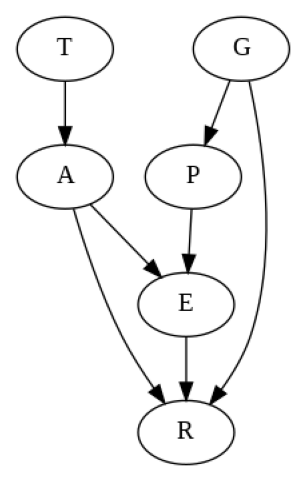

In [16]:
### Ejemplo para definir el grafo

from dowhy import CausalModel

#  MODELO CAUSAL DOWHY
causal_graph = """
digraph {
    T -> A;
    A -> E;
    G -> P;
    P -> E;
    E -> R;
    G -> R;
    A -> R;
}
"""

model = CausalModel(
    data=causal_df,
    treatment="E",        # variable de tratamiento: exposición
    outcome="R",          # variable de resultado: rating
    graph=causal_graph
)

model.view_model()

## 2. Define uno o varios modelos que te permintan estimar el efecto causal de la exposición E sobre el raitng R.

## 3. Estima el efecto causal de P sobre E y da una interpretación verbal de éste número.

## 4. ¿Podrías afirmar que hay un sesgo de popularidad en la exposición?

## 5. ¿Es G un confounder entre P y E?


Hint: Supongamos que model_P es el nombre del modelo que utilizaste para responder las dos preguntas anteriores. Utiliza `estimate_effect` con el parámetro

```
method_name="backdoor.linear_regression"
```

Como en el siguiente ejemplo:



```
#  identificación
estimand_P = model_P.identify_effect(proceed_when_unidentifiable=True)
print(estimand_P)  # aquí puedes ver qué variables backdoor encontró DoWhy

# estimación
estimate_P = model_P.estimate_effect(
    estimand_P,
    method_name="backdoor.linear_regression"  # backdoor
)
```



## 6. ¿Cuál es el efecto causal de A sobre E?

## 7. ¿Cuáles son las variables backdoor del efecto de A sobre E?

## 8. ¿Qué significa que el p-value de G sobre E sea tan alto?

El efecto causal de G sobre E es de -0.01649 con p-value de 0.96.
En general se obtiene:

```
efecto_original = -0.01649032188912003
efecto_perturbado = -0.01649032326284693
diferencia = 0.00000000137  # prácticamente cero
p-value = 0.96
```